In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Student_Academic_Performance_Dropout_250K.csv to Student_Academic_Performance_Dropout_250K (1).csv


In [ ]:
df = pd.read_csv("/content/Student_Academic_Performance_Dropout_250K.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Student_ID             250000 non-null  int64  
 1   Age                    250000 non-null  int64  
 2   Gender                 250000 non-null  object 
 3   Department             250000 non-null  object 
 4   Attendance             250000 non-null  int64  
 5   Study_Hours            250000 non-null  float64
 6   Internal_Marks         250000 non-null  int64  
 7   Assignment_Score       250000 non-null  int64  
 8   Mid_Exam_Marks         250000 non-null  int64  
 9   Final_Exam_Marks       250000 non-null  int64  
 10  Previous_GPA           250000 non-null  float64
 11  CGPA                   250000 non-null  float64
 12  Backlogs               250000 non-null  int64  
 13  Family_Income          250000 non-null  int64  
 14  Scholarship            250000 non-nu

In [ ]:
df.describe()

,Student_ID,Age,Attendance,Study_Hours,Internal_Marks,Assignment_Score,Mid_Exam_Marks,Final_Exam_Marks,Previous_GPA,CGPA,...,Family_Income,Scholarship,Hostel,Internet_Access,Sleep_Hours,Placement_Training,Extracurricular,Distance_From_College,Dropout_Risk_Score,Target_Dropout
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,20.503384,72.492964,4.246870,67.484116,64.846068,65.014808,62.513188,7.248757,5.187212,...,104918.600364,0.503272,0.499124,0.499756,6.492311,0.499568,0.500316,25.506772,23.520932,0.220468
std,72168.927986,2.290702,16.193422,2.167121,19.014446,20.509844,20.522289,21.951052,1.584694,0.962618,...,54907.935897,0.499990,0.500000,0.500001,1.443694,0.500001,0.500001,14.414537,14.986848,0.414563
min,1.000000,17.000000,45.000000,0.500000,35.000000,30.000000,30.000000,25.000000,4.500000,2.880000,...,10000.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,62500.750000,19.000000,58.000000,2.400000,51.000000,47.000000,47.000000,44.000000,5.880000,4.480000,...,57230.000000,0.000000,0.000000,0.000000,5.200000,0.000000,0.000000,13.000000,12.000000,0.000000
50%,125000.500000,21.000000,73.000000,4.200000,67.000000,65.000000,65.000000,63.000000,7.250000,5.190000,...,104764.000000,1.000000,0.000000,0.000000,6.500000,0.000000,1.000000,26.000000,21.900000,0.000000
75%,187500.250000,23.000000,87.000000,6.100000,84.000000,83.000000,83.000000,81.000000,8.620000,5.890000,...,152468.750000,1.000000,1.000000,1.000000,7.700000,1.000000,1.000000,38.000000,33.300000,0.000000
max,250000.000000,24.000000,100.000000,8.000000,100.000000,100.000000,100.000000,100.000000,10.000000,7.500000,...,199999.000000,1.000000,1.000000,1.000000,9.000000,1.000000,1.000000,50.000000,95.500000,1.000000


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Department,0
Attendance,0
Study_Hours,0
Internal_Marks,0
Assignment_Score,0
Mid_Exam_Marks,0
Final_Exam_Marks,0


In [ ]:
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
Department,object
Attendance,int64
Study_Hours,float64
Internal_Marks,int64
Assignment_Score,int64
Mid_Exam_Marks,int64
Final_Exam_Marks,int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

print("Duplicate Values Removed Successfully!")

Duplicate Values Removed Successfully!


In [ ]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Department', 'Attendance',
       'Study_Hours', 'Internal_Marks', 'Assignment_Score', 'Mid_Exam_Marks',
       'Final_Exam_Marks', 'Previous_GPA', 'CGPA', 'Backlogs', 'Family_Income',
       'Scholarship', 'Hostel', 'Internet_Access', 'Sleep_Hours',
       'Placement_Training', 'Extracurricular', 'Distance_From_College',
       'Stress_Level', 'Dropout_Risk_Score', 'Target_Dropout'],
      dtype='object')

In [ ]:
df.head()

,Student_ID,Age,Gender,Department,Attendance,Study_Hours,Internal_Marks,Assignment_Score,Mid_Exam_Marks,Final_Exam_Marks,...,Scholarship,Hostel,Internet_Access,Sleep_Hours,Placement_Training,Extracurricular,Distance_From_College,Stress_Level,Dropout_Risk_Score,Target_Dropout
0,1,18,Male,CIVIL,62,2.3,52,43,99,36,...,0,0,0,6.5,0,0,46,High,35.8,1
1,2,23,Male,IT,82,2.6,35,50,84,68,...,0,0,1,4.5,1,1,3,High,15.4,0
2,3,24,Male,IT,50,4.6,81,54,38,30,...,0,0,1,5.4,1,0,24,Medium,33.0,0
3,4,20,Female,CIVIL,88,5.4,56,98,61,45,...,0,1,0,5.1,0,1,26,Medium,12.6,0
4,5,18,Male,MECH,90,2.9,98,80,88,43,...,1,1,1,5.8,0,1,6,Low,13.2,0


In [ ]:
df.shape

(250000, 24)

In [ ]:
def attendance_level(x):
    if x >= 90:
        return "Excellent"
    elif x >= 75:
        return "Good"
    elif x >= 60:
        return "Average"
    else:
        return "Poor"

df["Attendance_Level"] = df["Attendance"].apply(attendance_level)

In [ ]:
def study_level(x):
    if x >= 6:
        return "High"
    elif x >= 4:
        return "Medium"
    else:
        return "Low"

df["Study_Level"] = df["Study_Hours"].apply(study_level)

In [ ]:
def gpa_level(x):
    if x >= 9:
        return "Excellent"
    elif x >= 8:
        return "Good"
    elif x >= 7:
        return "Average"
    else:
        return "Poor"

df["GPA_Level"] = df["CGPA"].apply(gpa_level)

In [ ]:
df["Backlog_Status"] = df["Backlogs"].apply(
    lambda x: "No Backlogs" if x == 0 else "Has Backlogs"
)

In [ ]:
df.head()

,Student_ID,Age,Gender,Department,Attendance,Study_Hours,Internal_Marks,Assignment_Score,Mid_Exam_Marks,Final_Exam_Marks,...,Placement_Training,Extracurricular,Distance_From_College,Stress_Level,Dropout_Risk_Score,Target_Dropout,Attendance_Level,Study_Level,GPA_Level,Backlog_Status
0,1,18,Male,CIVIL,62,2.3,52,43,99,36,...,0,0,46,High,35.8,1,Average,Low,Poor,No Backlogs
1,2,23,Male,IT,82,2.6,35,50,84,68,...,1,1,3,High,15.4,0,Good,Low,Poor,No Backlogs
2,3,24,Male,IT,50,4.6,81,54,38,30,...,1,0,24,Medium,33.0,0,Poor,Medium,Poor,No Backlogs
3,4,20,Female,CIVIL,88,5.4,56,98,61,45,...,0,1,26,Medium,12.6,0,Good,Medium,Poor,No Backlogs
4,5,18,Male,MECH,90,2.9,98,80,88,43,...,0,1,6,Low,13.2,0,Excellent,Low,Poor,No Backlogs


In [ ]:
df["Target_Dropout"].value_counts()

,count
Target_Dropout,
0,194883
1,55117


In [ ]:
df.drop("Dropout_Risk_Score", axis=1, inplace=True)

In [ ]:
df["Total_Marks"] = (
    df["Internal_Marks"] +
    df["Assignment_Score"] +
    df["Mid_Exam_Marks"] +
    df["Final_Exam_Marks"]
)

In [ ]:
df.drop([
    "Internal_Marks",
    "Assignment_Score",
    "Mid_Exam_Marks",
    "Final_Exam_Marks"
], axis=1, inplace=True)

In [ ]:
df.head()

,Student_ID,Age,Gender,Department,Attendance,Study_Hours,Previous_GPA,CGPA,Backlogs,Family_Income,...,Placement_Training,Extracurricular,Distance_From_College,Stress_Level,Target_Dropout,Attendance_Level,Study_Level,GPA_Level,Backlog_Status,Total_Marks
0,1,18,Male,CIVIL,62,2.3,7.75,4.78,0,17811,...,0,0,46,High,1,Average,Low,Poor,No Backlogs,230
1,2,23,Male,IT,82,2.6,6.03,4.71,0,98236,...,1,1,3,High,0,Good,Low,Poor,No Backlogs,237
2,3,24,Male,IT,50,4.6,8.14,4.82,0,30916,...,1,0,24,Medium,0,Poor,Medium,Poor,No Backlogs,203
3,4,20,Female,CIVIL,88,5.4,7.04,4.64,0,177772,...,0,1,26,Medium,0,Good,Medium,Poor,No Backlogs,260
4,5,18,Male,MECH,90,2.9,5.96,4.05,0,157159,...,0,1,6,Low,0,Excellent,Low,Poor,No Backlogs,309


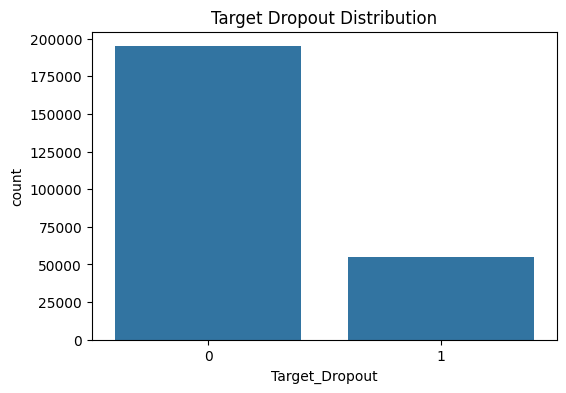

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target_Dropout", data=df)
plt.title("Target Dropout Distribution")
plt.show()

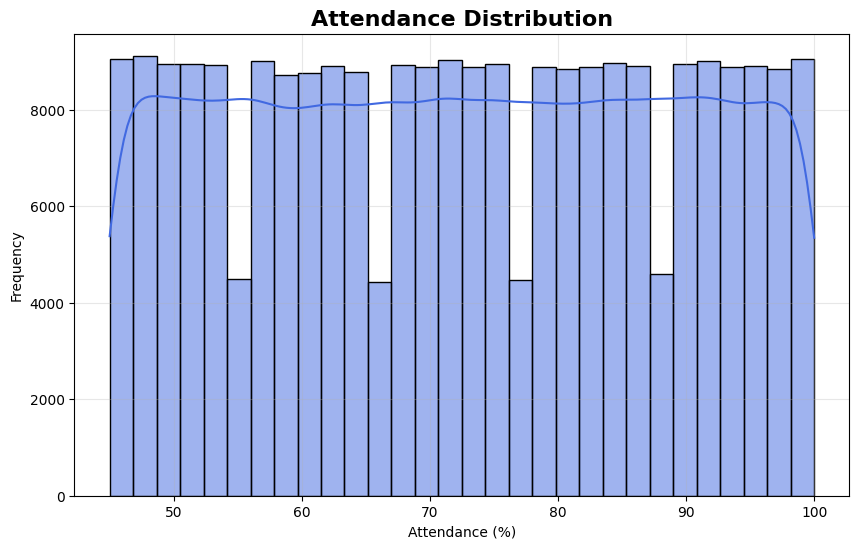

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Attendance'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title('Attendance Distribution',fontsize=16,fontweight='bold')
plt.xlabel('Attendance (%)')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)

plt.show()

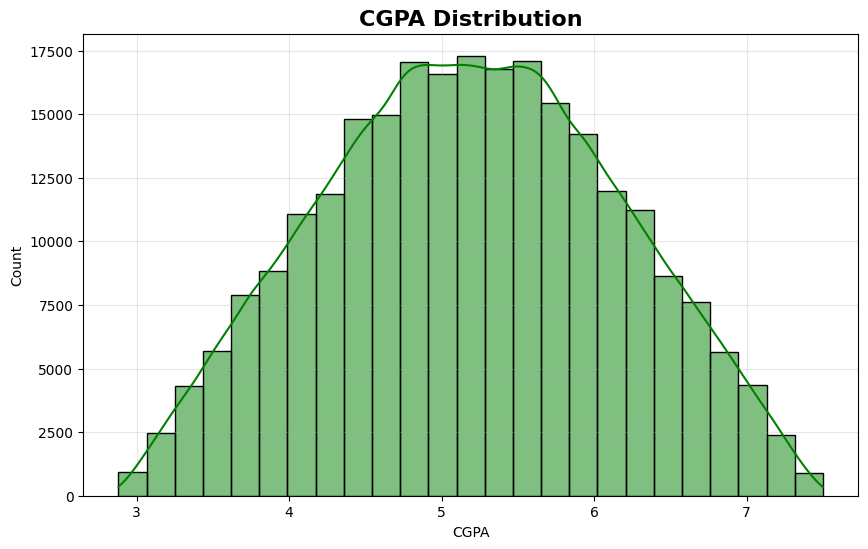

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['CGPA'],
    bins=25,
    kde=True,
    color='green'
)

plt.title("CGPA Distribution",fontsize=16,fontweight='bold')
plt.xlabel("CGPA")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

/tmp/ipykernel_2033/2025434542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


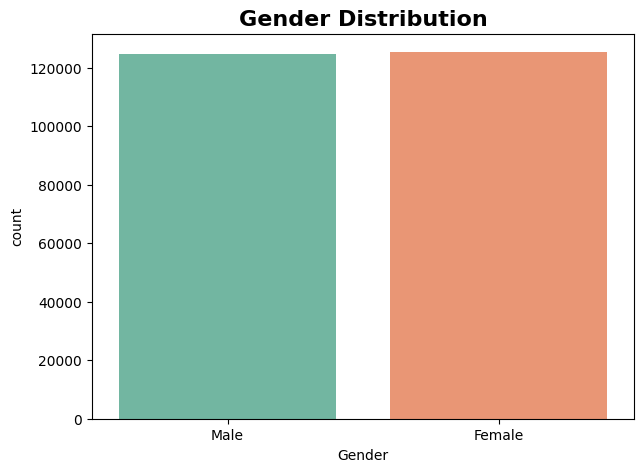

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Gender',
    data=df,
    palette='Set2'
)

plt.title("Gender Distribution",fontsize=16,fontweight='bold')

plt.show()

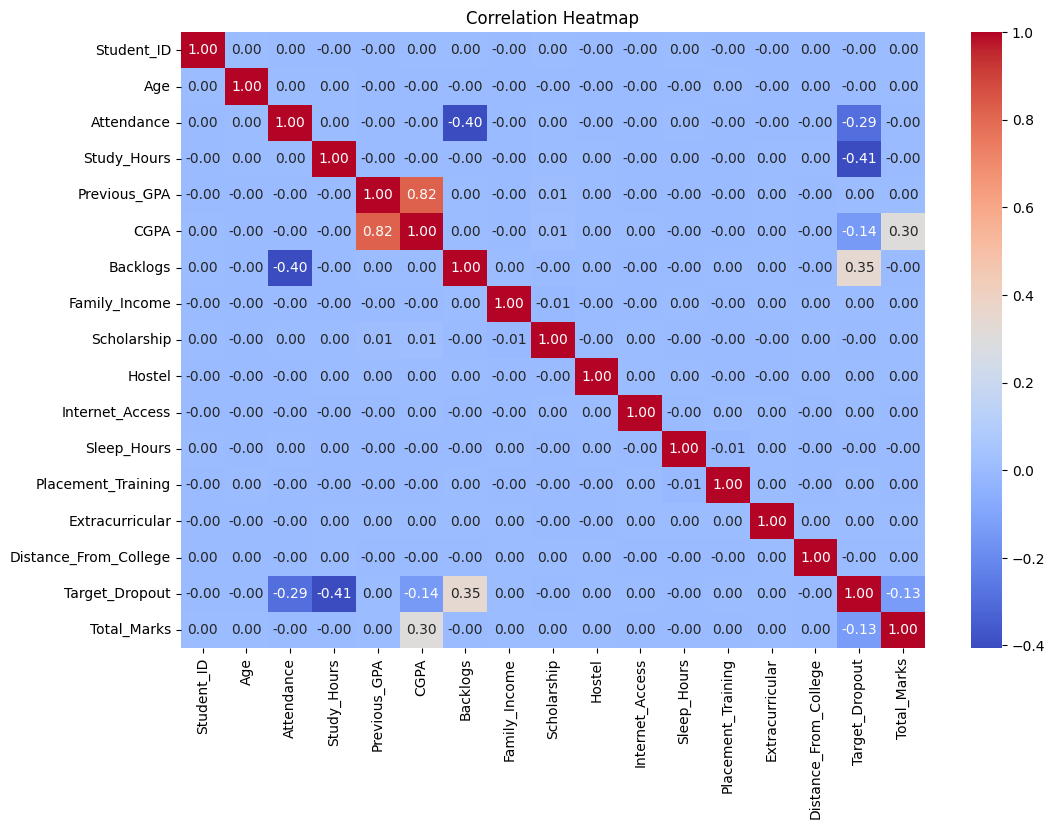

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

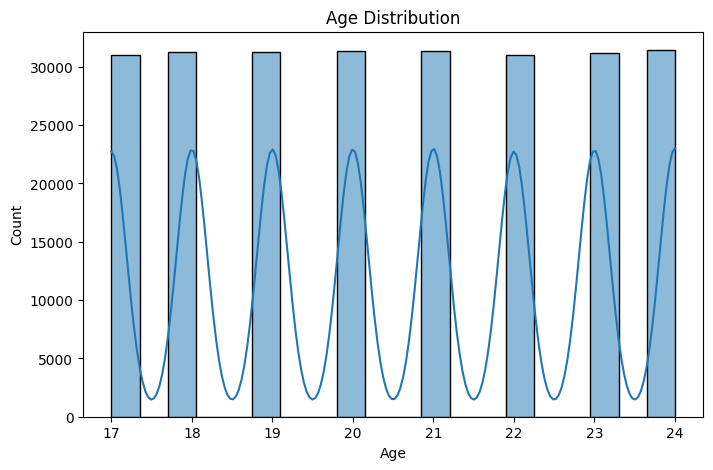

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


In [ ]:
# Convert categorical columns into numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("Categorical Columns Encoded Successfully!")

Categorical Columns Encoded Successfully!


In [ ]:
df.head()

,Student_ID,Age,Gender,Department,Attendance,Study_Hours,Previous_GPA,CGPA,Backlogs,Family_Income,...,Placement_Training,Extracurricular,Distance_From_College,Stress_Level,Target_Dropout,Attendance_Level,Study_Level,GPA_Level,Backlog_Status,Total_Marks
0,1,18,1,1,62,2.3,7.75,4.78,0,17811,...,0,0,46,0,1,0,1,1,1,230
1,2,23,1,5,82,2.6,6.03,4.71,0,98236,...,1,1,3,0,0,2,1,1,1,237
2,3,24,1,5,50,4.6,8.14,4.82,0,30916,...,1,0,24,2,0,3,2,1,1,203
3,4,20,0,1,88,5.4,7.04,4.64,0,177772,...,0,1,26,2,0,2,2,1,1,260
4,5,18,1,6,90,2.9,5.96,4.05,0,157159,...,0,1,6,1,0,1,1,1,1,309


In [ ]:
# Features
X = df.drop("Target_Dropout", axis=1)

# Target
y = df["Target_Dropout"]

In [ ]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (250000, 23)
y Shape : (250000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (200000, 23)
Testing Data : (50000, 23)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9699


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     39108
           1       0.97      0.88      0.93     10892

    accuracy                           0.97     50000
   macro avg       0.97      0.94      0.95     50000
weighted avg       0.97      0.97      0.97     50000



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38857   251]
 [ 1254  9638]]


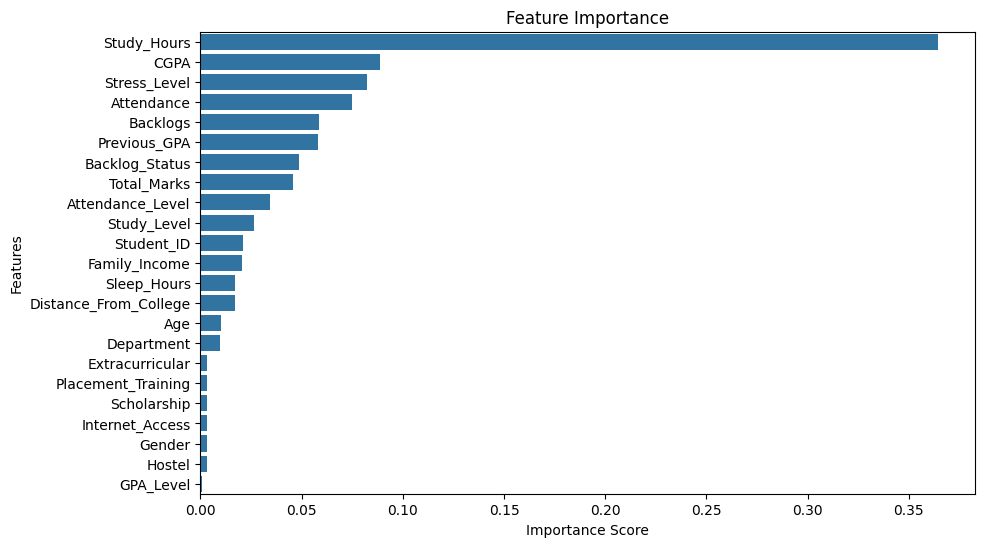

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
new_student = pd.DataFrame({
    "Student_ID":[250001],
    "Age":[20],
    "Gender":[1],
    "Department":[2],
    "Attendance":[85],
    "Study_Hours":[5],
    "Previous_GPA":[8.2],
    "CGPA":[8.4],
    "Backlogs":[0],
    "Family_Income":[2],
    "Scholarship":[1],
    "Hostel":[0],
    "Internet_Access":[1],
    "Sleep_Hours":[7],
    "Placement_Training":[1],
    "Extracurricular":[1],
    "Distance_From_College":[12],
    "Stress_Level":[2],
    "Attendance_Level":[2],
    "Study_Level":[1],
    "GPA_Level":[1],
    "Backlog_Status":[1],
    "Total_Marks":[320]
})

prediction = rf.predict(new_student)

print(prediction)

[0]


In [ ]:
if prediction[0] == 0:
    print("✅ Student is Not Likely to Drop Out")
else:
    print("⚠️ Student is Likely to Drop Out")

✅ Student is Not Likely to Drop Out
